In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel


/home/taliyah/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
date_data = pd.read_csv("./SpeedDatingData.csv", encoding="latin-1", keep_default_na="false")

data = date_data[
    ~date_data['dec'].isna() & 
    ~date_data['shar'].isna() & 
    ~date_data['intel'].isna() & 
    ~date_data['attr'].isna()
    ]

y = data["dec"].values
x = data[ ["shar" , "intel" , "attr"] ].values

In [3]:
x = (x - np.mean(x)) / np.std(x)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [26]:
data_dict = {
    'N': len(y_train),
    'K': 3,
    'KM': len(X_test),
    'ym': y_train,
    'xm': X_train,
    'xtest': X_test,
    'ytest': y_test,
}

model = CmdStanModel(stan_file="./h4_3model.stan")

fit = model.sample(data=data_dict, chains=4, iter_sampling=1500, iter_warmup=500)


23:50:27 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/inter/CompOrg/Tnmp/h4/h4_3model.stan to exe file /mnt/c/Users/inter/CompOrg/Tnmp/h4/h4_3model
23:50:43 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/inter/CompOrg/Tnmp/h4/h4_3model
23:50:43 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|                                                                       | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|                                                                       | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|                                                                       | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 2:   5%|███                                                         | 100/2000 [00:00<00:03, 513.30it/s, (Warmup)]

chain 1:  10%|██████                                                      | 200/2000 [00:00<00:03, 567.05it/s, (Warmup)]

chain 2:  10%|██████                                                      


23:50:47 - cmdstanpy - INFO - CmdStan done processing.


In [27]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-3016.220000,0.024315,1.356650e+00,1.210470,-3018.820000,-3015.920000,-3014.600000,3085.91,4216.01,280.155,1.00075
alpha,-0.044624,0.000713,4.370550e-02,0.043079,-0.116934,-0.044662,0.028116,3814.53,4512.14,346.303,1.00040
beta[1],0.628526,0.000544,3.711750e-02,0.037051,0.568352,0.628305,0.691716,4661.77,4346.54,423.220,1.00178
beta[2],-0.080520,0.000796,5.021900e-02,0.050567,-0.163829,-0.079984,0.001759,3989.14,3860.10,362.155,1.00070
beta[3],1.199290,0.000678,4.657840e-02,0.047131,1.123370,1.199760,1.275960,4734.50,4021.76,429.823,1.00033
...,...,...,...,...,...,...,...,...,...,...,...
temp2,86.500000,NaN,0.000000e+00,0.000000,86.500000,86.500000,86.500000,NaN,NaN,NaN,NaN
temp3,-15.776800,0.230732,1.801230e+01,17.791200,-45.000000,-16.000000,14.000000,6185.40,5477.94,561.544,1.00043
test_against,-0.010858,0.000159,1.239660e-02,0.012245,-0.030970,-0.011012,0.009635,6185.40,5477.94,561.544,1.00042
class_acc,0.059532,NaN,8.119180e-16,0.000000,0.059532,0.059532,0.059532,NaN,NaN,NaN,NaN


In [28]:
fit.stan_variable("alpha")
fit.stan_variable("beta")

array([[ 0.65260087, -0.11211069,  1.2173999 ],
       [ 0.70859665, -0.06617489,  1.1810909 ],
       [ 0.69961876, -0.0486144 ,  1.1813387 ],
       ...,
       [ 0.6741791 , -0.08847939,  1.2079978 ],
       [ 0.66559549, -0.044398  ,  1.1741392 ],
       [ 0.59942103,  0.02654779,  1.2463694 ]], shape=(6000, 3))

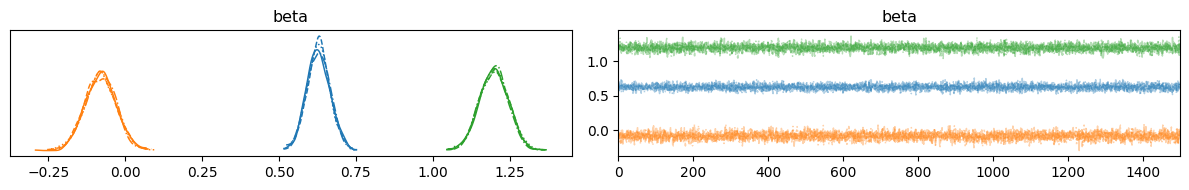

In [29]:
axarr = az.plot_trace(fit.draws_xr("beta"))
plt.tight_layout()

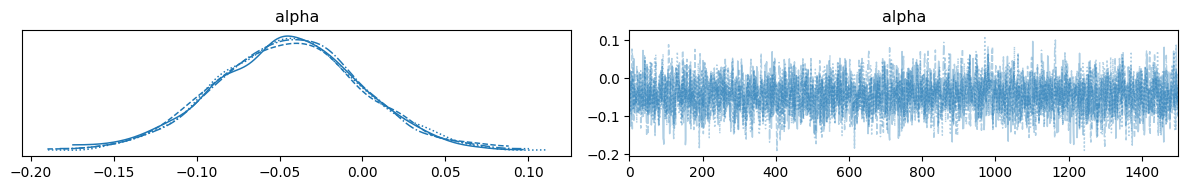

In [30]:
axarr = az.plot_trace(fit.draws_xr("alpha"))
plt.tight_layout()

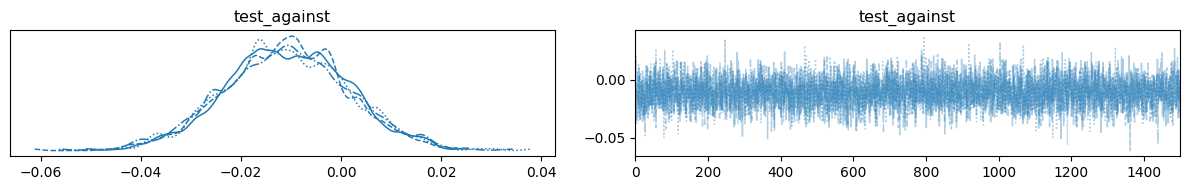

In [31]:
axarr = az.plot_trace(fit.draws_xr("test_against"))
plt.tight_layout()

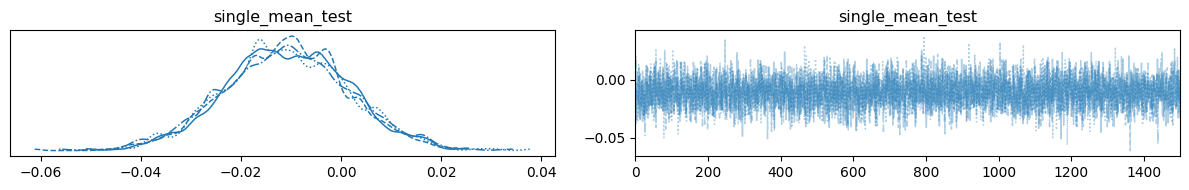

In [32]:
axarr = az.plot_trace(fit.draws_xr("single_mean_test"))
plt.tight_layout()